# 03 — Model Training v3 (LOUO Cross-Validation + IDCNN)

1. **Leave-One-User-Out CV** — quick run (30 epochs) on all 10 users to get honest accuracy estimate
2. **Final IDCNN training** — full run (100 epochs) on augmented data with users 3-10
3. **Evaluate on test users** (1, 2)

In [13]:
import numpy as np
import pickle
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, regularizers, callbacks
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print(f'TensorFlow: {tf.__version__}')
print(f'GPUs: {tf.config.list_physical_devices("GPU")}')

TensorFlow: 2.13.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Load Data

In [10]:
DATA_DIR = Path('../data/processed')
MODEL_DIR = Path('../models')
RESULTS_DIR = Path('../results')
MODEL_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

# Augmented train/test (for final training)
X_train_aug = np.load(DATA_DIR / 'X_train.npy')
y_train_aug = np.load(DATA_DIR / 'y_train.npy')
X_test = np.load(DATA_DIR / 'X_test.npy')
y_test = np.load(DATA_DIR / 'y_test.npy')

# All windows with user labels (for LOUO CV)
X_all = np.load(DATA_DIR / 'X_all.npy')
y_all = np.load(DATA_DIR / 'y_all.npy')
users_all = np.load(DATA_DIR / 'users_all.npy')

with open(DATA_DIR / 'preprocessing_info.pkl', 'rb') as f:
    info = pickle.load(f)

NUM_CLASSES = info['num_classes']
WINDOW_SIZE = info['window_size']
NUM_FEATURES = info['num_features']
ACTIVITIES = info['activities']
ALL_USERS = sorted(set(users_all))

print(f'Augmented train: {X_train_aug.shape}')
print(f'Test: {X_test.shape}')
print(f'All data (for LOUO): {X_all.shape}')
print(f'Classes: {NUM_CLASSES} | Features: {NUM_FEATURES}')
print(f'Users: {ALL_USERS}')

Augmented train: (29727, 128, 8)
Test: (1018, 128, 8)
All data (for LOUO): (10927, 128, 8)
Classes: 11 | Features: 8
Users: [2, 3, 5, 6, 7, 8, 10, 14, 15, 16]


## 2. IDCNN Architecture

In [14]:
L2_REG = 1e-4

def inception_dilated_block(x, filters, dilation_rates, l2=L2_REG):
    """Inception block with parallel dilated convolutions."""
    branches = []
    for rate in dilation_rates:
        branch = layers.Conv1D(
            filters, kernel_size=3, dilation_rate=rate, padding='same',
            kernel_regularizer=regularizers.l2(l2)
        )(x)
        branch = layers.BatchNormalization()(branch)
        branch = layers.Activation('relu')(branch)
        branches.append(branch)
    
    branch_1x1 = layers.Conv1D(filters, kernel_size=1, padding='same',
                                kernel_regularizer=regularizers.l2(l2))(x)
    branch_1x1 = layers.BatchNormalization()(branch_1x1)
    branch_1x1 = layers.Activation('relu')(branch_1x1)
    branches.append(branch_1x1)
    
    merged = layers.Concatenate()(branches)
    
    out = layers.Conv1D(filters * 2, kernel_size=1, padding='same',
                        kernel_regularizer=regularizers.l2(l2))(merged)
    out = layers.BatchNormalization()(out)
    out = layers.Activation('relu')(out)
    return out


def build_idcnn(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    
    x = layers.Conv1D(32, kernel_size=7, padding='same',
                      kernel_regularizer=regularizers.l2(L2_REG))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.15)(x)
    
    x = inception_dilated_block(x, filters=16, dilation_rates=[1, 2, 4, 8])
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.2)(x)
    
    x = inception_dilated_block(x, filters=24, dilation_rates=[1, 2, 4])
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.25)(x)
    
    x = inception_dilated_block(x, filters=32, dilation_rates=[1, 2])
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.3)(x)
    
    x = layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(L2_REG))(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    return Model(inputs, outputs, name='IDCNN')


# Quick check
test_model = build_idcnn((WINDOW_SIZE, NUM_FEATURES), NUM_CLASSES)
print(f'IDCNN parameters: {test_model.count_params():,}')
del test_model

IDCNN parameters: 47,307


## 3. Leave-One-User-Out Cross-Validation

For each of 10 users: train on 9 users, test on 1.  
Uses **non-augmented** data and **30 epochs** for speed.  
Gives the most honest estimate of how the model generalizes to unseen users.

In [ ]:
LOUO_EPOCHS = 30
LOUO_BATCH_SIZE = 64

louo_results = []

for fold_idx, test_user in enumerate(ALL_USERS):
    print(f'\n{"="*50}')
    print(f'LOUO Fold {fold_idx+1}/{len(ALL_USERS)}: test_user={test_user}')
    print(f'{"="*50}')
    
    # Split
    test_mask = users_all == test_user
    X_fold_train = X_all[~test_mask]
    y_fold_train = y_all[~test_mask]
    X_fold_test = X_all[test_mask]
    y_fold_test = y_all[test_mask]
    
    print(f'  Train: {len(X_fold_train)} | Test: {len(X_fold_test)}')
    
    # Class weights for this fold
    cw_arr = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES), y=y_fold_train)
    cw = {i: w for i, w in enumerate(cw_arr)}
    
    # Build and train
    model = build_idcnn((WINDOW_SIZE, NUM_FEATURES), NUM_CLASSES)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    
    model.fit(
        X_fold_train, y_fold_train,
        validation_data=(X_fold_test, y_fold_test),
        epochs=LOUO_EPOCHS,
        batch_size=LOUO_BATCH_SIZE,
        class_weight=cw,
        callbacks=[
            callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0),
            callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=0),
        ],
        verbose=0,
    )
    
    fold_loss, fold_acc = model.evaluate(X_fold_test, y_fold_test, verbose=0)
    louo_results.append({'user': test_user, 'acc': fold_acc, 'loss': fold_loss, 'n_test': len(X_fold_test)})
    print(f'  Result: acc={fold_acc:.4f}, loss={fold_loss:.4f}')
    
    # Clean up GPU memory
    del model
    tf.keras.backend.clear_session()

print(f'\n{"="*50}')
print('LOUO CROSS-VALIDATION SUMMARY')
print(f'{"="*50}')


LOUO Fold 1/10: test_user=2
  Train: 9909 | Test: 1018


2026-04-29 15:00:19.453018: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-04-29 15:00:37.595656: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


  Result: acc=0.6159, loss=1.1776

LOUO Fold 2/10: test_user=3
  Train: 9993 | Test: 934


2026-04-29 15:05:34.172255: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-04-29 15:05:52.636917: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


  Result: acc=0.8415, loss=0.5079

LOUO Fold 3/10: test_user=5
  Train: 10123 | Test: 804


2026-04-29 17:22:50.646437: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-04-29 17:23:09.972883: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


  Result: acc=0.6430, loss=1.0818

LOUO Fold 4/10: test_user=6
  Train: 9982 | Test: 945


2026-04-29 18:41:09.145930: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


  User      Acc     Loss   N_test
-----------------------------------
     2   0.6159   1.1776     1018
     3   0.8415   0.5079      934
     5   0.6430   1.0818      804

Mean accuracy:     0.7002 +/- 0.1006
Weighted accuracy: 0.7003
Best user:  3 (0.8415)
Worst user: 2 (0.6159)


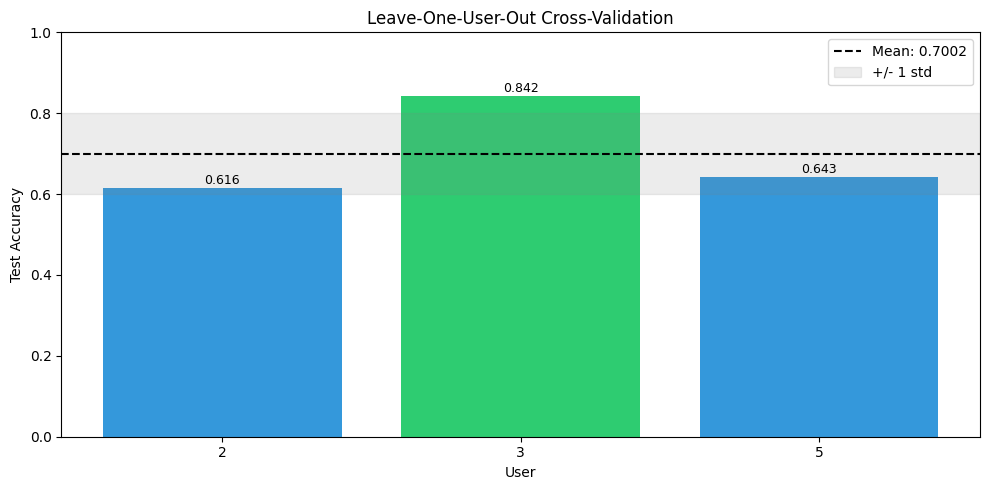

In [15]:
# LOUO results summary
print(f'{"User":>6} {"Acc":>8} {"Loss":>8} {"N_test":>8}')
print('-' * 35)
for r in louo_results:
    print(f'{r["user"]:>6} {r["acc"]:>8.4f} {r["loss"]:>8.4f} {r["n_test"]:>8}')

# Weighted average (by number of test samples)
total_samples = sum(r['n_test'] for r in louo_results)
weighted_acc = sum(r['acc'] * r['n_test'] for r in louo_results) / total_samples
mean_acc = np.mean([r['acc'] for r in louo_results])
std_acc = np.std([r['acc'] for r in louo_results])

print(f'\nMean accuracy:     {mean_acc:.4f} +/- {std_acc:.4f}')
print(f'Weighted accuracy: {weighted_acc:.4f}')
print(f'Best user:  {max(louo_results, key=lambda r: r["acc"])["user"]} ({max(r["acc"] for r in louo_results):.4f})')
print(f'Worst user: {min(louo_results, key=lambda r: r["acc"])["user"]} ({min(r["acc"] for r in louo_results):.4f})')

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
users = [r['user'] for r in louo_results]
accs = [r['acc'] for r in louo_results]
colors = ['#e74c3c' if a < mean_acc - std_acc else '#2ecc71' if a > mean_acc + std_acc else '#3498db' for a in accs]
ax.bar([str(u) for u in users], accs, color=colors)
ax.axhline(y=mean_acc, color='black', linestyle='--', label=f'Mean: {mean_acc:.4f}')
ax.axhspan(mean_acc - std_acc, mean_acc + std_acc, alpha=0.15, color='gray', label=f'+/- 1 std')
ax.set_xlabel('User')
ax.set_ylabel('Test Accuracy')
ax.set_title('Leave-One-User-Out Cross-Validation')
ax.legend()
ax.set_ylim(0, 1)
for i, v in enumerate(accs):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'louo_cv_results.png', dpi=150)
plt.show()

---
## 4. Final Model Training

Full training on augmented data (users 3-10) with 100 epochs.

In [16]:
EPOCHS = 100
BATCH_SIZE = 64

print('Final training configuration:')
print(f'  Train data: {X_train_aug.shape}')
print(f'  Test data:  {X_test.shape}')
print(f'  Epochs: {EPOCHS}, Batch: {BATCH_SIZE}')

# Class weights
cw_arr = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES), y=y_train_aug)
class_weights = {i: w for i, w in enumerate(cw_arr)}

# Build model
model = build_idcnn((WINDOW_SIZE, NUM_FEATURES), NUM_CLASSES)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
model.summary()

Final training configuration:
  Train data: (29727, 128, 8)
  Test data:  (1018, 128, 8)
  Epochs: 100, Batch: 64


Model: "IDCNN"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_3 (InputLayer)        [(None, 128, 8)]             0         []                            
                                                                                                  
 conv1d_32 (Conv1D)          (None, 128, 32)              1824      ['input_3[0][0]']             
                                                                                                  
 batch_normalization_32 (Ba  (None, 128, 32)              128       ['conv1d_32[0][0]']           
 tchNormalization)                                                                                
                                                                                                  
 activation_32 (Activation)  (None, 128, 32)              0         ['batch_normalization_32[0

In [17]:
history = model.fit(
    X_train_aug, y_train_aug,
    validation_split=0.15,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1),
        callbacks.ModelCheckpoint(str(MODEL_DIR / 'best_idcnn_v3.h5'), monitor='val_loss',
                                  save_best_only=True, verbose=0),
    ],
    verbose=1,
)

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'\nFinal Test Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}')

Epoch 1/100


2026-04-29 19:06:25.022065: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


395/395 [==============================] - ETA: 0s - loss: 1.3554 - accuracy: 0.5515

2026-04-29 19:07:11.030349: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


395/395 [==============================] - 53s 125ms/step - loss: 1.3554 - accuracy: 0.5515 - val_loss: 0.8742 - val_accuracy: 0.7090 - lr: 0.0010
Epoch 2/100
395/395 [==============================] - 52s 130ms/step - loss: 0.9250 - accuracy: 0.7004 - val_loss: 0.7074 - val_accuracy: 0.7612 - lr: 0.0010
Epoch 3/100
395/395 [==============================] - 57s 145ms/step - loss: 0.7934 - accuracy: 0.7455 - val_loss: 0.6166 - val_accuracy: 0.7944 - lr: 0.0010
Epoch 4/100
395/395 [==============================] - 58s 145ms/step - loss: 0.7203 - accuracy: 0.7691 - val_loss: 0.5815 - val_accuracy: 0.8090 - lr: 0.0010
Epoch 5/100
395/395 [==============================] - 57s 144ms/step - loss: 0.6654 - accuracy: 0.7856 - val_loss: 0.5529 - val_accuracy: 0.8119 - lr: 0.0010
Epoch 6/100
395/395 [==============================] - 54s 136ms/step - loss: 0.6302 - accuracy: 0.7999 - val_loss: 0.5402 - val_accuracy: 0.8224 - lr: 0.0010
Epoch 7/100
395/395 [==============================] - 52s

## 5. Results

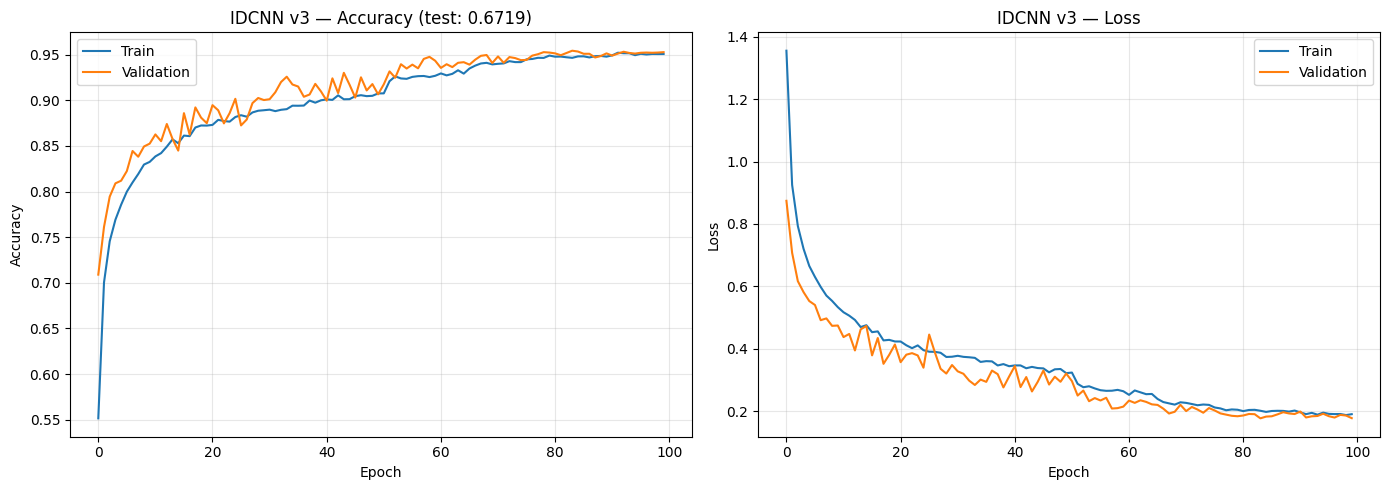

In [18]:
# Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title(f'IDCNN v3 — Accuracy (test: {test_acc:.4f})')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('IDCNN v3 — Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'idcnn_v3_training_history.png', dpi=150)
plt.show()

2026-04-30 02:02:18.565208: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


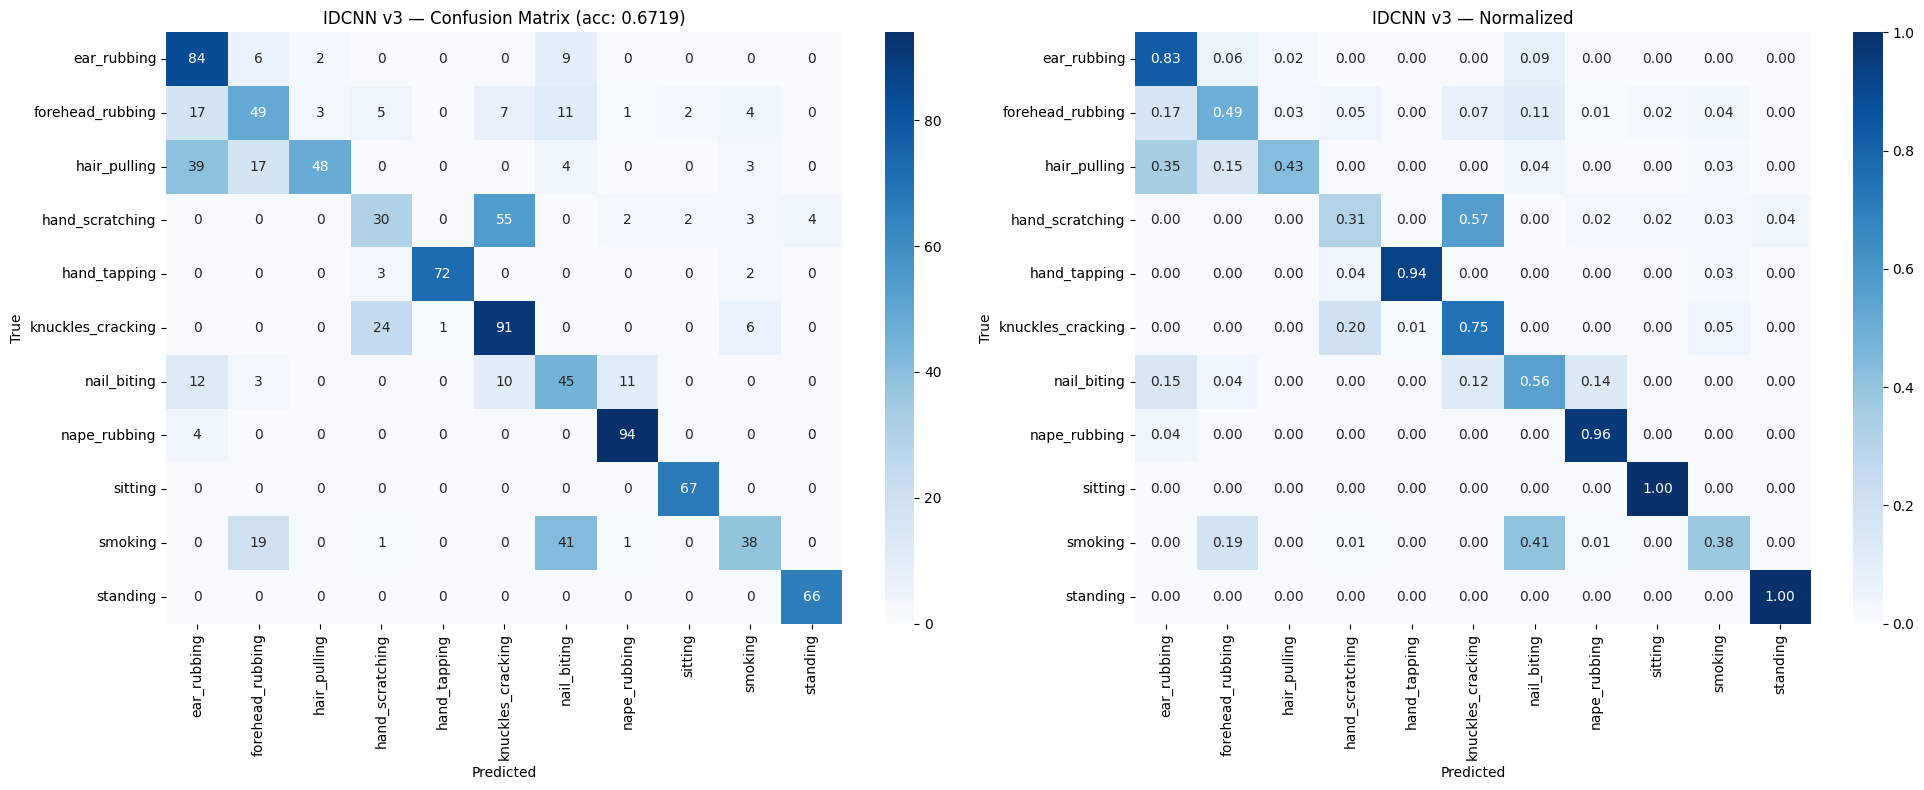

                   precision    recall  f1-score   support

      ear_rubbing     0.5385    0.8317    0.6537       101
 forehead_rubbing     0.5213    0.4949    0.5078        99
     hair_pulling     0.9057    0.4324    0.5854       111
  hand_scratching     0.4762    0.3125    0.3774        96
     hand_tapping     0.9863    0.9351    0.9600        77
knuckles_cracking     0.5583    0.7459    0.6386       122
      nail_biting     0.4091    0.5556    0.4712        81
     nape_rubbing     0.8624    0.9592    0.9082        98
          sitting     0.9437    1.0000    0.9710        67
          smoking     0.6786    0.3800    0.4872       100
         standing     0.9429    1.0000    0.9706        66

         accuracy                         0.6719      1018
        macro avg     0.7112    0.6952    0.6846      1018
     weighted avg     0.6947    0.6719    0.6624      1018



In [19]:
# Confusion matrix
y_pred = model.predict(X_test, verbose=0).argmax(axis=1)
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=ACTIVITIES,
            yticklabels=ACTIVITIES, ax=ax1)
ax1.set_title(f'IDCNN v3 — Confusion Matrix (acc: {test_acc:.4f})')
ax1.set_ylabel('True')
ax1.set_xlabel('Predicted')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=ACTIVITIES,
            yticklabels=ACTIVITIES, ax=ax2)
ax2.set_title('IDCNN v3 — Normalized')
ax2.set_ylabel('True')
ax2.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'idcnn_v3_confusion_matrix.png', dpi=150)
plt.show()

print(classification_report(y_test, y_pred, target_names=ACTIVITIES, digits=4))

## 6. Comparison: v2 vs v3

In [20]:
print('COMPARISON')
print('=' * 55)
print(f'{"":20s} {"v2 (no user norm)":>18s} {"v3 (user norm)":>18s}')
print('-' * 55)
print(f'{"Features":20s} {"6 (raw)":>18s} {"8 (raw+mag)":>18s}')
print(f'{"Per-user norm":20s} {"No":>18s} {"Yes":>18s}')
print(f'{"Test accuracy":20s} {"0.5963":>18s} {test_acc:>18.4f}')
print(f'{"LOUO mean acc":20s} {"N/A":>18s} {mean_acc:>18.4f}')
print(f'{"LOUO std":20s} {"N/A":>18s} {std_acc:>18.4f}')
improvement = (test_acc - 0.5963) * 100
print(f'\nImprovement: {improvement:+.2f} percentage points')

COMPARISON
                      v2 (no user norm)     v3 (user norm)
-------------------------------------------------------
Features                        6 (raw)        8 (raw+mag)
Per-user norm                        No                Yes
Test accuracy                    0.5963             0.6719
LOUO mean acc                       N/A             0.7002
LOUO std                            N/A             0.1006

Improvement: +7.56 percentage points


## 7. Save

In [21]:
model.save(MODEL_DIR / 'best_model_v3.h5')

training_info = {
    'best_model': 'IDCNN_v3',
    'test_accuracy': float(test_acc),
    'test_loss': float(test_loss),
    'louo_results': louo_results,
    'louo_mean_acc': float(mean_acc),
    'louo_std_acc': float(std_acc),
    'louo_weighted_acc': float(weighted_acc),
    'num_classes': NUM_CLASSES,
    'activities': ACTIVITIES,
    'window_size': WINDOW_SIZE,
    'num_features': NUM_FEATURES,
    'epochs': EPOCHS,
    'batch_size': BATCH_SIZE,
    'l2_reg': L2_REG,
    'class_weights': class_weights,
    'history': history.history,
    'params': model.count_params(),
}

with open(MODEL_DIR / 'training_info_v3.pkl', 'wb') as f:
    pickle.dump(training_info, f)

print(f'Model saved to models/best_model_v3.h5')
print(f'Parameters: {model.count_params():,}')
print(f'Test accuracy: {test_acc:.4f}')
print(f'LOUO accuracy: {mean_acc:.4f} +/- {std_acc:.4f}')
print(f'\nNext: run 04_quantization_v3.ipynb')

Model saved to models/best_model_v3.h5
Parameters: 47,307
Test accuracy: 0.6719
LOUO accuracy: 0.7002 +/- 0.1006

Next: run 04_quantization_v3.ipynb
